# Image generation with Conditional Diffusion Model
Questo notebook consente di generare immagini a partire da un modello di diffusione già addestrato, usando le condizioni `male`, `no_beard` e `glasses`.

In [ ]:
import torch
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from ddpm import DDPMUNet, NoiseSchedule, TimeEncoding, COND_SHAPE, IMAGE_SHAPE, generate

device = "cuda" if torch.cuda.is_available() else "cpu"
L = 1000
noise_schedule = NoiseSchedule(L)
time_encoding = TimeEncoding(L, 64)
model = DDPMUNet()

model.to(device)

model.load_state_dict(torch.load('../weights/ddpm.pth', map_location=device)['model_state_dict'])


model.eval()

cond_one_hot = torch.eye(COND_SHAPE[0], device=device)

/var/folders/kk/wwyfxsf503q6kl7_5hvpmrd40000gn/T/ipykernel_2748/3110884547.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../weights/

In [5]:
def generate_condition_combinations():
    batch_size = 2
    condition_values = [0, 1]
    all_conditions = [
        (m, nb, g)
        for m in condition_values
        for nb in condition_values
        for g in condition_values
    ]

    num_rows = len(all_conditions)

    num_cols = 1 + batch_size

    plt.figure(figsize=(1.5 * num_cols,  num_rows))

    with torch.no_grad():
        for idx, (m, nb, g) in enumerate(all_conditions):
            desc = f"Male: {m}\nNoBeard: {nb}\nGlasses: {g}"

            male = cond_one_hot[m].unsqueeze(0).repeat(batch_size, 1)
            no_beard = cond_one_hot[nb].unsqueeze(0).repeat(batch_size, 1)
            glasses = cond_one_hot[g].unsqueeze(0).repeat(batch_size, 1)
            gen = generate(model, male, no_beard, glasses, lam=3.0).cpu()

            
            plt.subplot(num_rows, num_cols, idx * num_cols + 1)
            plt.text(0.5, 0.5, desc, horizontalalignment='center', verticalalignment='center',
                     fontsize=10, transform=plt.gca().transAxes) 
            plt.axis('off') 


            for i in range(batch_size):
                plt.subplot(num_rows, num_cols, idx * num_cols + i + 2) 
                plt.imshow(gen[i].permute(1, 2, 0).clamp(0, 1))
                plt.axis('off')

        plt.tight_layout() 
        plt.show()


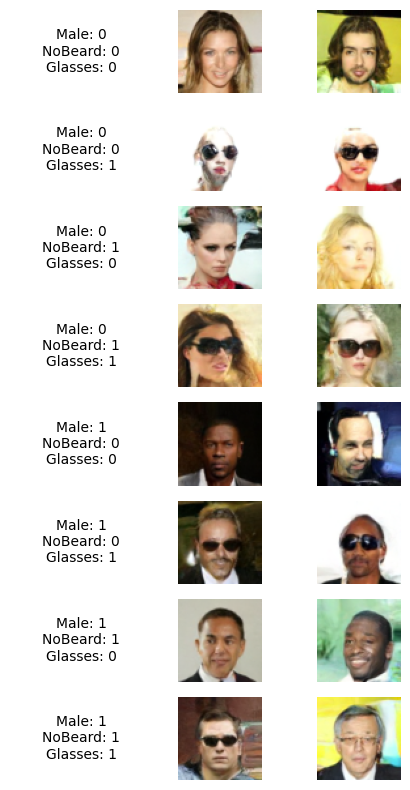

In [6]:
generate_condition_combinations()
